1. Entrenar el modelo

In [3]:
from ultralytics import YOLO

# Cargar un modelo base (pequeño y rápido para prácticas)
model = YOLO('yolo11n.pt')

# Entrenar con tu dataset
results = model.train(
    data='datasets/data.yaml',  
    epochs=20,                            
    imgsz=640,                            
    project='runs'                       
)

New https://pypi.org/project/ultralytics/8.4.11 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.249 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=

2. Cargar el modelo entrenado

In [ ]:
model = YOLO('runs/train2/weights/best.pt')

In [ ]:
img_path = 'datasets/test/images/test_164_jpg.rf.e4f3bd6ef4f5ea8957647fe9e8b13fe2.jpg'
resultados = model(img_path)

print(f"Objetos detectados inicialmente: {len(resultados[0].boxes)}")

In [ ]:
from collections import Counter

UMBRAL_CONF = 0.1

prediccion = resultados[0]
cajas_totales = prediccion.boxes

boxes_filtradas = [box for box in cajas_totales if box.conf > UMBRAL_CONF]
print(f"Objetos reales tras filtrar (Confianza > {UMBRAL_CONF}): {len(boxes_filtradas)}")

ids_clases = [int(box.cls) for box in boxes_filtradas]
conteos = Counter(ids_clases)

print("\n REPORTE DE INVENTARIO:")
nombres_clases = model.names
for clase_id, cantidad in conteos.items():
    nombre_obj = nombres_clases[clase_id]
    print(f" -> {nombre_obj}: {cantidad} unidades")

Objetos reales tras filtrar (Confianza > 0.1): 0

 REPORTE DE INVENTARIO:


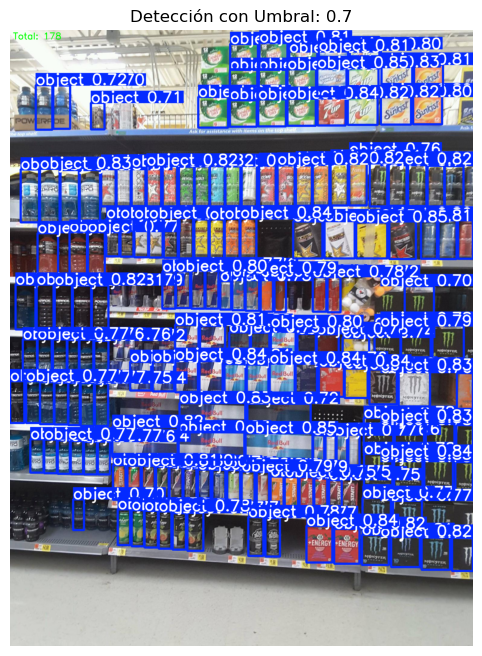

In [14]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt

def visualizar_conteo(prediccion, boxes_filtradas, conteos, umbral):
    prediccion.boxes = prediccion.boxes[prediccion.boxes.conf > umbral]

    img_resultado = prediccion.plot()

    nombres = prediccion.names
    texto_conteo = ", ".join([f"{nombres[c]}: {n}" for c, n in conteos.items()])

    cv2.putText(img_resultado, f"Total: {len(boxes_filtradas)}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Detección con Umbral: {umbral}")
    plt.show()

visualizar_conteo(resultados[0], boxes_filtradas, conteos, UMBRAL_CONF)


image 1/1 /home/ciabd01/Documentos/CEIABD/MIA/ConteodeObjetos_3.6/datasets/test/images/val_410_jpg.rf.cb80d87b456af9b8ea954c0407fe0b2d.jpg: 640x480 221 objects, 6.0ms
Speed: 2.4ms preprocess, 6.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)


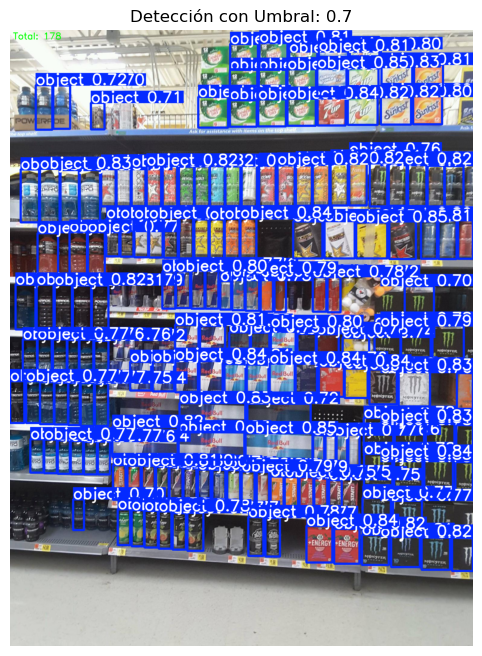

Imagen: datasets/test/images/val_410_jpg.rf.cb80d87b456af9b8ea954c0407fe0b2d.jpg -> Productos detectados: 178

image 1/1 /home/ciabd01/Documentos/CEIABD/MIA/ConteodeObjetos_3.6/datasets/test/images/train_1358_jpg.rf.21236f5e0e3b4db56d7f5193be6c5075.jpg: 640x480 139 objects, 5.1ms
Speed: 1.5ms preprocess, 5.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)


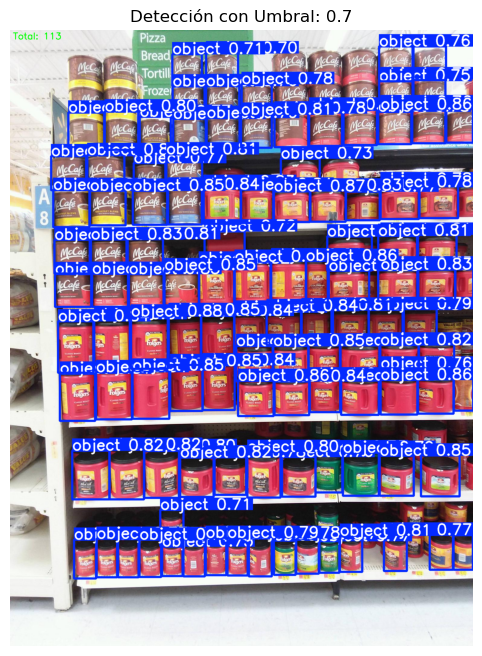

Imagen: datasets/test/images/train_1358_jpg.rf.21236f5e0e3b4db56d7f5193be6c5075.jpg -> Productos detectados: 113

image 1/1 /home/ciabd01/Documentos/CEIABD/MIA/ConteodeObjetos_3.6/datasets/test/images/train_4855_jpg.rf.e43b1c003e8e33756ffa55b9c1658880.jpg: 480x640 230 objects, 5.3ms
Speed: 1.3ms preprocess, 5.3ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


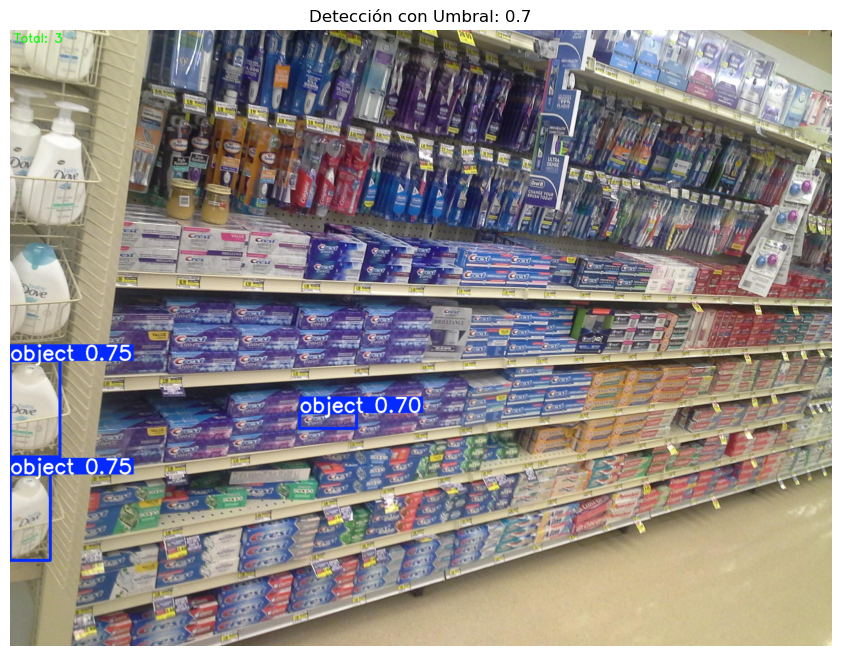

Imagen: datasets/test/images/train_4855_jpg.rf.e43b1c003e8e33756ffa55b9c1658880.jpg -> Productos detectados: 3


In [15]:
%matplotlib inline

def analizar_estanteria(ruta_imagen):
    resultados = model(ruta_imagen)

    prediccion = resultados[0]
    boxes_filtradas = [box for box in prediccion.boxes if box.conf > UMBRAL_CONF]

    ids_clases = [int(box.cls) for box in boxes_filtradas]
    conteos = Counter(ids_clases)

    visualizar_conteo(prediccion, boxes_filtradas, conteos, UMBRAL_CONF)

    return len(boxes_filtradas)

# Ejecutar en las primeras 3 imágenes de test
rutas_test = glob.glob('datasets/test/images/*.jpg')

for ruta in rutas_test[:3]:
    total = analizar_estanteria(ruta)
    print(f"Imagen: {ruta} -> Productos detectados: {total}")